# 02 - Duplicates, leakage and the cleaned manifest

**Goal:** find images that appear more than once (or look almost the same), decide which ones to remove, and record the decision in `reports/manifest.csv`.

**Safety rule:** this notebook never deletes, moves or edits an image. It only reads files and writes tables.

**Why it matters:** if the same vehicle is in `train` and `test`, the model has already seen the test image and the test score looks better than it really is (*leakage*). If the same image has two different labels, the data contradicts itself.

The heavy code lives in `src/duplicates.py`, `src/duplicates_plots.py` and `src/clean_manifest.py`.

## 1. Setup

In [1]:
import os
import sys

# If the notebook is opened from notebooks/, move to the project root.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

Working directory: d:\maktab\145\tvc-clean


In [2]:
from pathlib import Path

import pandas as pd
from IPython.display import Image as show_image

from src.utils import load_config, set_seed
from src.duplicates_plots import plot_pair_grid

cfg = load_config()
set_seed(cfg["seed"])
data_dir = cfg["paths"]["data_dir"]
reports = Path(cfg["paths"]["reports_dir"])
explore = reports / "figures" / "explore"
explore.mkdir(parents=True, exist_ok=True)

## 2. How we measure "the same image"

- **Exact duplicate:** two files that are identical byte by byte. Found with an `MD5` hash (a short fingerprint of the file).
- **Near duplicate:** two images that *look* alike. Found with a perceptual hash (`phash`), a 64-bit fingerprint of how the picture looks. The **Hamming distance** is the number of bits that differ: 0 means almost surely the same picture, larger numbers mean more different.

We did not trust any distance limit blindly. We looked at real pairs and decided with our own eyes.

## 3. Load the saved tables

In [3]:
hashes = pd.read_csv(reports / "hashes.csv")
pairs = pd.read_csv(reports / "duplicate_pairs.csv")
print("images hashed:", len(hashes), "| close pairs saved (distance <= %d):" % cfg["duplicates"]["max_distance"], len(pairs))
print("\nNumber of pairs at each exact distance:")
print(pairs["distance"].value_counts().sort_index().to_string())

images hashed: 4360 | close pairs saved (distance <= 8): 1367

Number of pairs at each exact distance:
distance
0     28
2     36
4    100
6    332
8    871


The numbers are *cumulative* in the earlier summary (pairs with distance <= 4 include the ones with distance 0), but here every pair is counted once at its exact distance. Only even distances appear.

## 4. Exact duplicates

In [4]:
groups = hashes.groupby("md5").filter(lambda g: len(g) > 1)
print("Groups of byte-identical files:", groups["md5"].nunique(), "| images inside those groups:", len(groups))

Groups of byte-identical files: 24 | images inside those groups: 48


## 5. Looking at pairs by distance

Six random pairs for each distance. For each pair ask one question: *same vehicle in the same moment, or two different vehicles?*

Saved reports\figures\explore\nb_pairs_distance_0.png


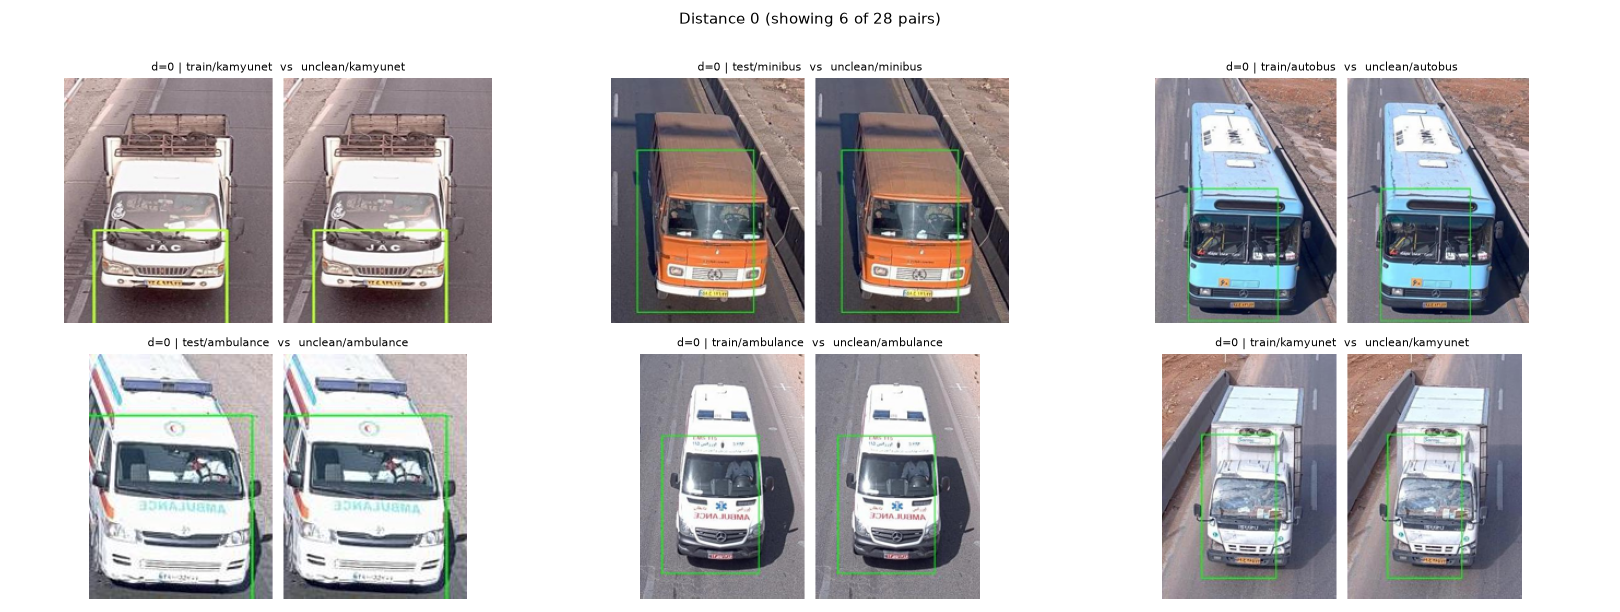

Saved reports\figures\explore\nb_pairs_distance_2.png


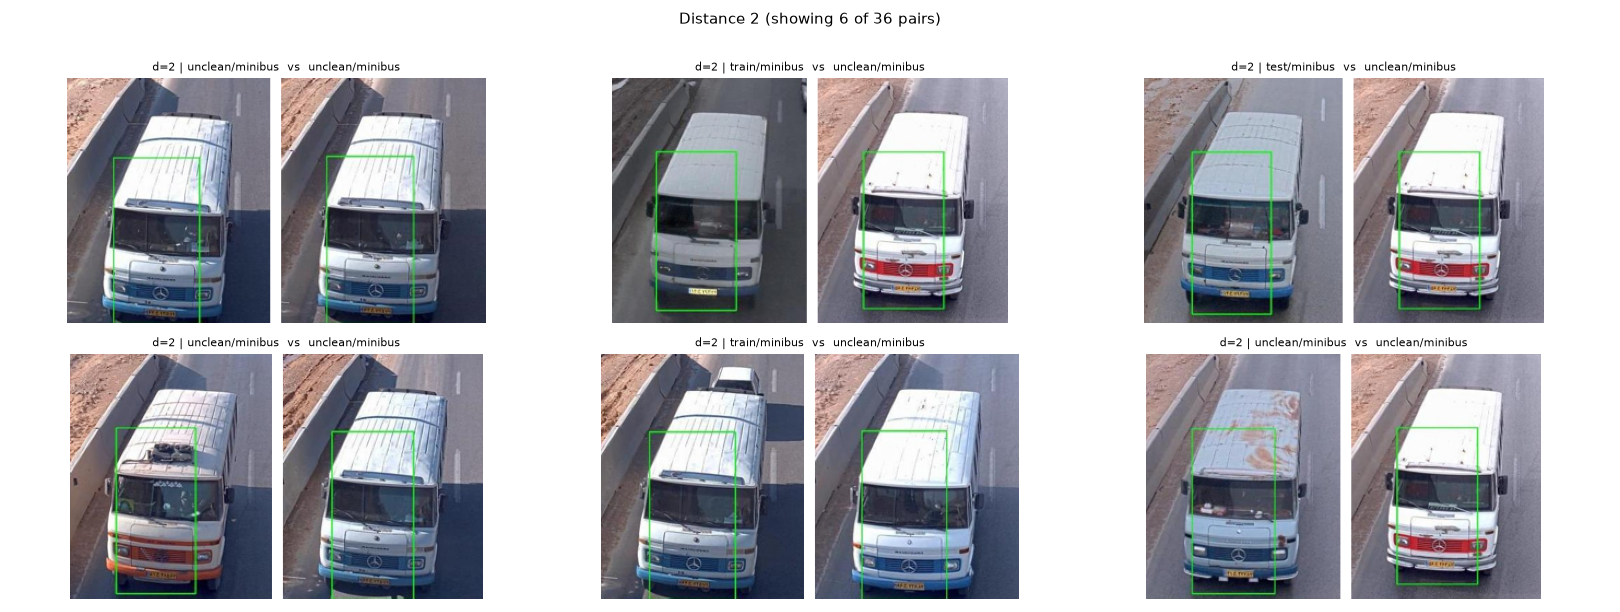

Saved reports\figures\explore\nb_pairs_distance_4.png


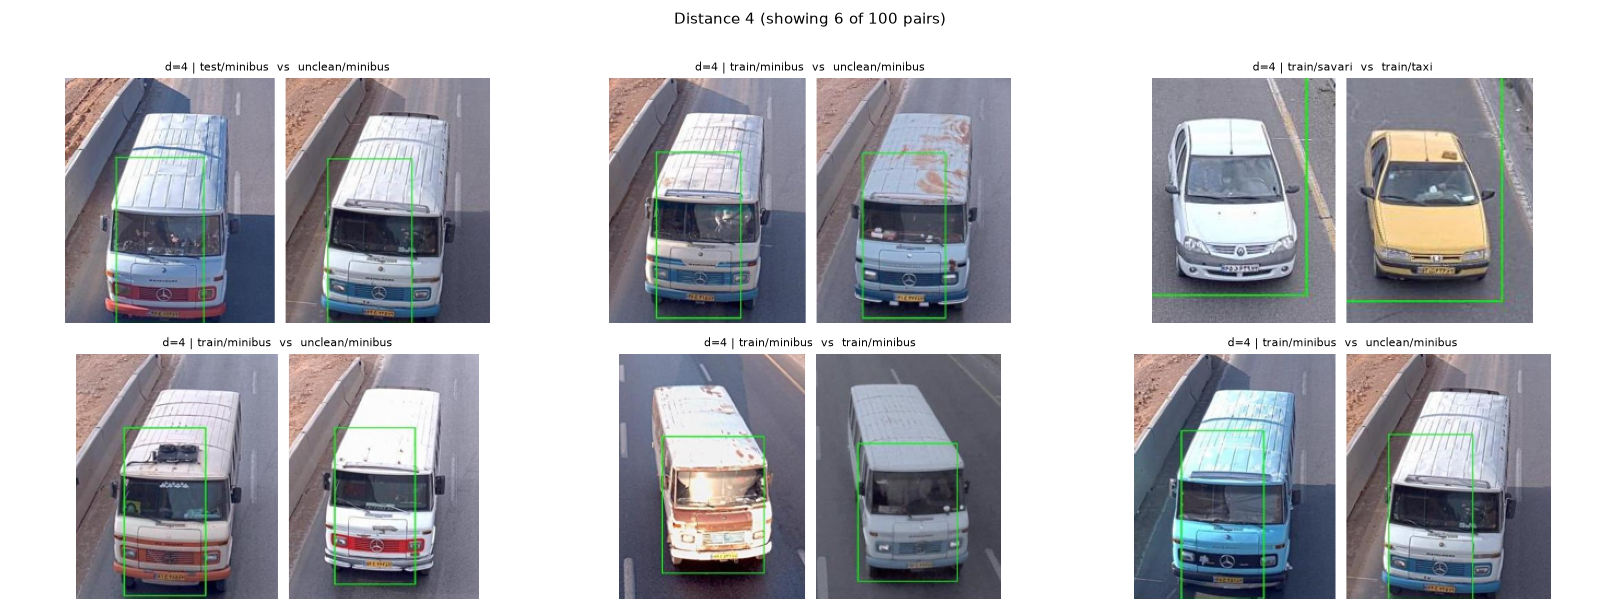

Saved reports\figures\explore\nb_pairs_distance_6.png


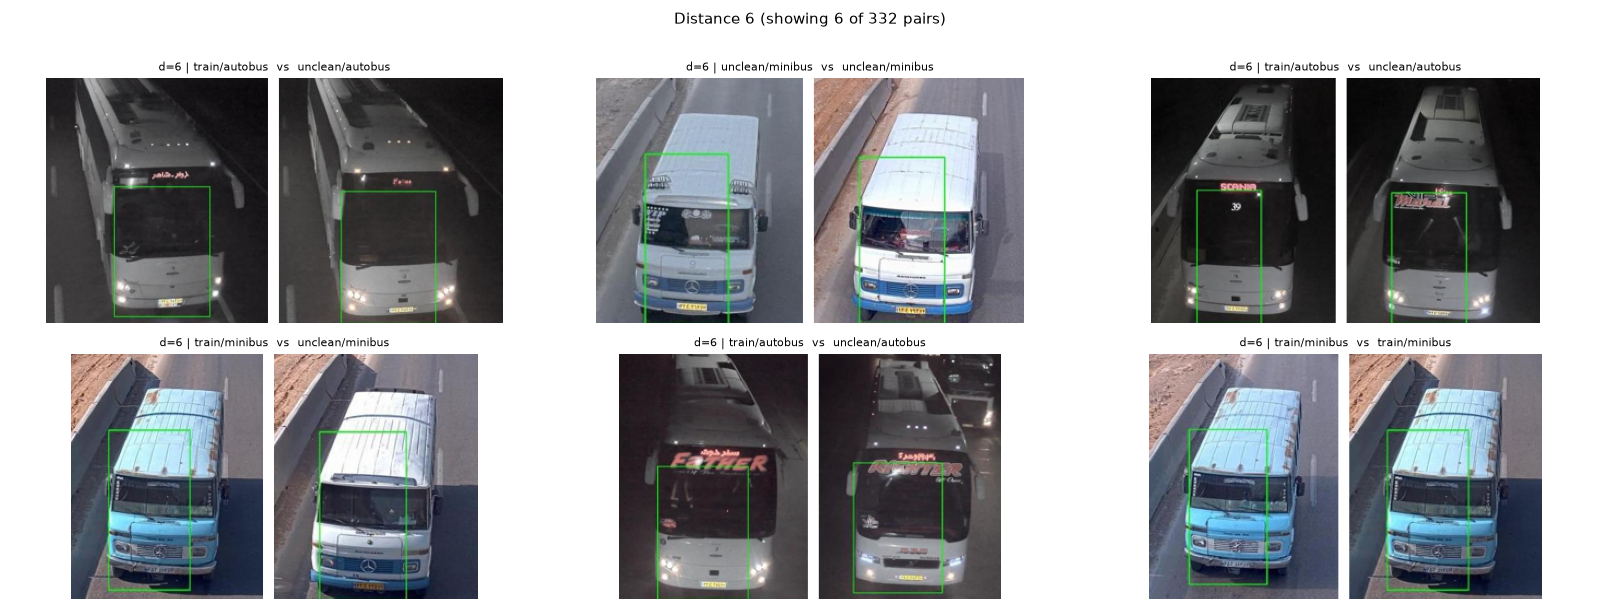

Saved reports\figures\explore\nb_pairs_distance_8.png


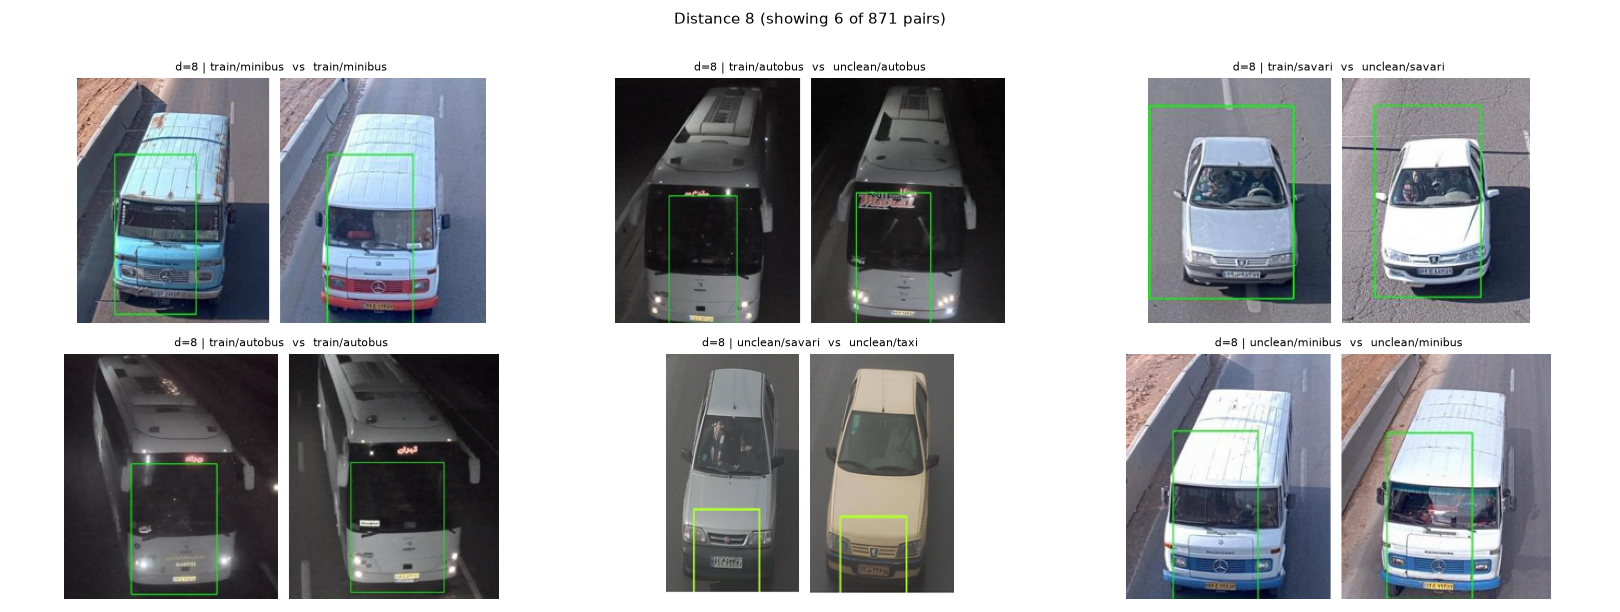

In [5]:
for d in sorted(pairs["distance"].unique()):
    out = explore / f"nb_pairs_distance_{d}.png"
    plot_pair_grid(pairs[pairs["distance"] == d], data_dir, out,
                   f"Distance {d}", max_pairs=6, seed=cfg["seed"])
    display(show_image(filename=str(out)))

**What we saw:** distance 0 is always the same picture. From distance 2 upward the pairs get mixed (same vehicle in neighbouring frames, but also different white minibuses on the same road). At distance 6 and 8 most pairs are different vehicles. The camera is fixed, so the road and the concrete wall look alike in every image and the fingerprint confuses them.

So only distance 0 is safe for automatic removal inside `train` and `unclean`.

## 6. Test leakage: train images that look like a test image

Saved reports\figures\explore\nb_train_vs_test.png


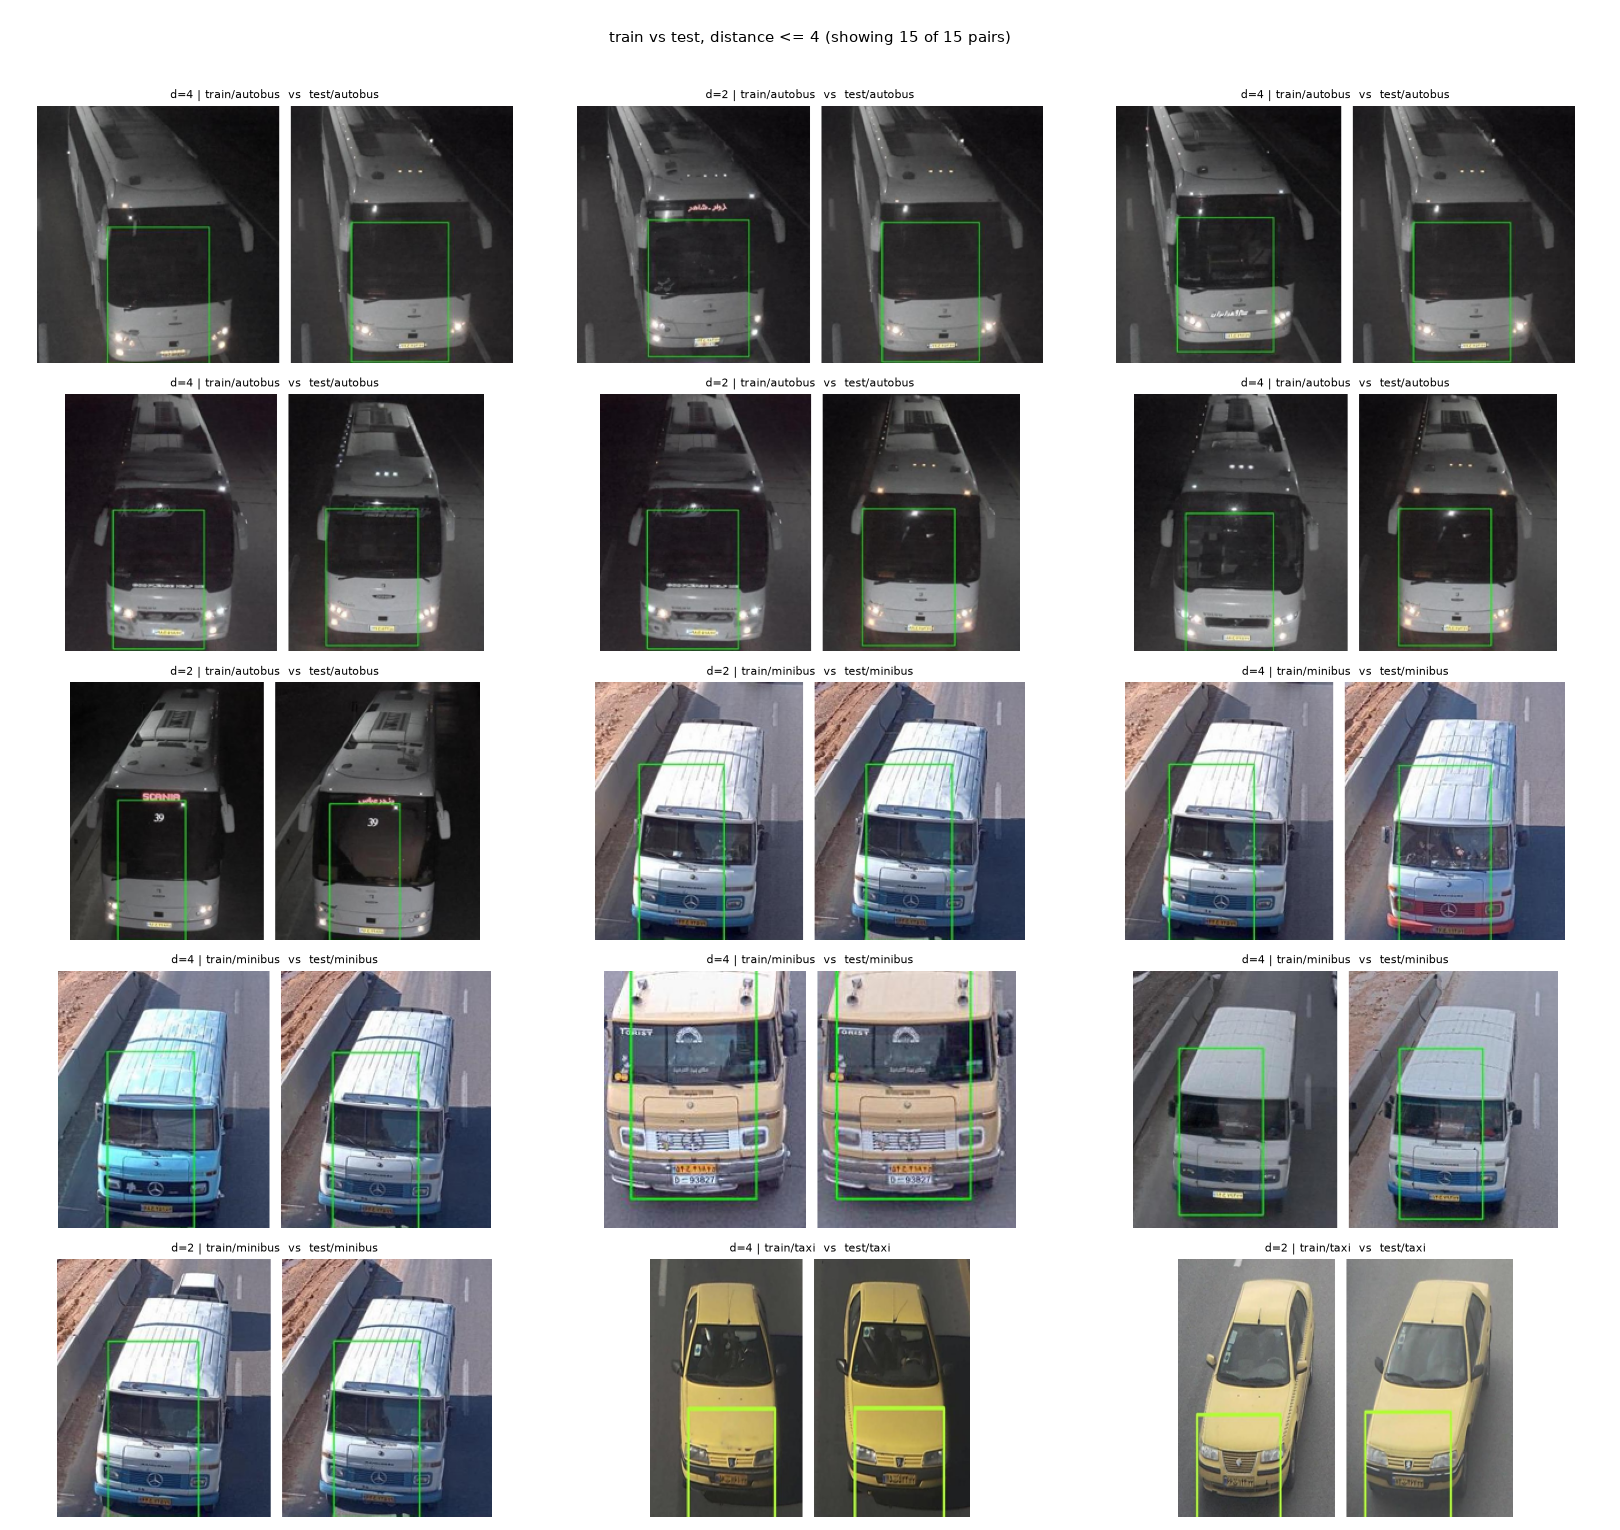

In [6]:
cross = pairs[(pairs["split_a"] == "train") & (pairs["split_b"] == "test") & (pairs["distance"] <= cfg["duplicates"]["near_test_distance"])]
out = explore / "nb_train_vs_test.png"
plot_pair_grid(cross, data_dir, out, "train vs test, distance <= 4", max_pairs=30, seed=cfg["seed"])
display(show_image(filename=str(out)))

Most of these pairs look like **the same vehicle in consecutive frames** (for example six pairs of the same night bus). So the original dataset already has some leakage between `train` and `test`. This is more than exact copies: one real vehicle can appear on both sides.

## 7. Pairs that look alike but have different labels

Saved reports\figures\explore\nb_label_conflicts.png


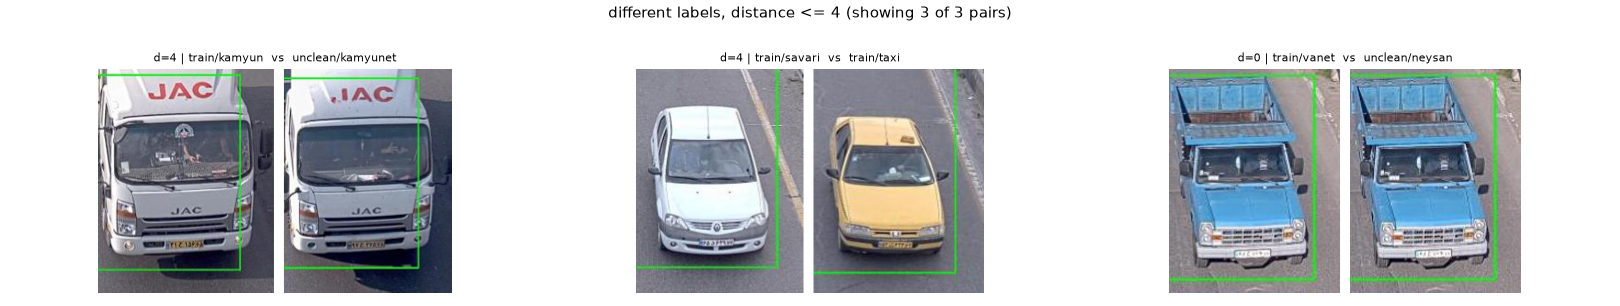

,path_a,path_b,class_a,class_b,distance
272,train/kamyun/216040476.jpg,unclean/kamyunet/214105935.jpg,kamyun,kamyunet,4
798,train/savari/216019459.jpg,train/taxi/214833819.jpg,savari,taxi,4
950,train/vanet/214844236.jpg,unclean/neysan/214844236.jpg,vanet,neysan,0


In [7]:
conflicts = pairs[(~pairs["same_class"]) & (pairs["distance"] <= cfg["duplicates"]["near_test_distance"])]
out = explore / "nb_label_conflicts.png"
plot_pair_grid(conflicts, data_dir, out, "different labels, distance <= 4", max_pairs=30, seed=cfg["seed"])
display(show_image(filename=str(out)))
conflicts[["path_a", "path_b", "class_a", "class_b", "distance"]]

Only three pairs:
1. `savari` vs `taxi`: different cars, a false alarm.
2. Two JAC trucks labelled `kamyun` and `kamyunet`: the same kind of truck, so the border between these two classes is blurry. We keep this in mind for the error analysis.
3. A blue pickup at distance **0** labelled `vanet` (train) and `neysan` (unclean): one image with two labels, a real conflict.

## 8. Cleaning rules

The first rule that applies wins.

| Situation | Decision | Reason |
|---|---|---|
| Image in `test` | never changed | the test set is frozen |
| `neysan` image (unseen class) | kept aside for later analysis | the model must not learn it |
| `train`/`unclean` image with distance <= 4 to a test image | dropped | protects the test set; losing a few images is cheap |
| Distance 0 and different labels | dropped | the label cannot be trusted |
| Distance 0 and the same label | keep only the first | true duplicate |
| Everything else | `keep` (train) or `unclean_candidate` (unclean) | |

Pairs at distance 2 to 8 *inside* `train` are not removed. Most are different vehicles. Later, when we make the validation set, close images will be kept on the same side so that validation is not inflated.

## 9. The cleaned manifest (built by `python -m src.clean_manifest`)

In [8]:
manifest = pd.read_csv(reports / "manifest.csv")
print(manifest.groupby(["split", "status"]).size().unstack(fill_value=0).T)
print("\nTraining images kept, per class:")
print(manifest[manifest["status"] == "keep"]["class"].value_counts().sort_index().to_string())

split                test  train  unclean
status                                   
drop_duplicate          0      0       15
drop_label_conflict     0      1        0
drop_near_test          0     13       25
keep                    0   1918        0
test_frozen           400      0        0
unclean_candidate       0      0     1738
unseen_class            0      0      250

Training images kept, per class:
class
ambulance    219
autobus      239
kamyun       250
kamyunet     238
minibus      225
savari       250
taxi         248
vanet        249


## 10. Safety checks

In [9]:
assert len(manifest) == len(hashes)
assert (manifest.loc[manifest["split"] == "test", "status"] == "test_frozen").all()
assert (manifest.loc[manifest["status"] == "test_frozen", "split"] == "test").all()

keep = manifest[manifest["status"] == "keep"]
assert not keep["class"].isin(cfg["duplicates"]["unseen_classes"]).any()

close = pairs[pairs["distance"] <= cfg["duplicates"]["near_test_distance"]]
leaky = set(close[(close["split_b"] == "test") & (close["split_a"] != "test")]["path_a"]) | \
        set(close[(close["split_a"] == "test") & (close["split_b"] != "test")]["path_b"])
assert set(keep["path"]).isdisjoint(leaky)
print("All checks passed: test untouched, no unseen class in training, no near-test image kept.")

All checks passed: test untouched, no unseen class in training, no near-test image kept.


## 11. Findings

- **Exact duplicates:** 24 groups (48 images) of byte-identical files.
- **Distance 0:** 28 pairs, all the same picture. They sit between `train`/`test` and `unclean`, or inside `unclean`. There is none between `train` and `test`.
- **Test leakage:** 15 pairs between `train` and `test` with distance <= 4, mostly the same vehicle in consecutive frames. 13 `train` images and 25 `unclean` images were dropped because they look like a test image.
- **Unreliable distances:** from distance 2 upward, many pairs are different vehicles on the same fixed-camera background. An automatic rule would remove good images, so we use only distance 0 inside `train`/`unclean`.
- **Label conflicts:** 3 pairs at distance <= 4; only one (`vanet` vs `neysan`) is a real conflict. `kamyun` vs `kamyunet` looks blurry and will be checked again in the error analysis.
- **Result:** 1,918 of 1,932 `train` images kept (14 removed), 400 `test` images untouched, 1,738 `unclean` images kept as candidates, 250 `neysan` images set aside.

**Next step:** build the train/validation split from the kept images, keeping near-identical images on the same side.